In [1]:
from langgraph.graph import StateGraph,  START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict

In [2]:
load_dotenv()

model = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.7
)

In [18]:
class CricketState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    boundary_percentage: float
    ball_per_boundary: float
    summary: str

In [19]:
def calculate_strike_rate(state: CricketState):
    sr = (state['runs']/state['balls'])*100
    return {'strike_rate': sr}

In [20]:
def calculate_bounday_percentage(state: CricketState):
    bp = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
    return {'boundary_percentage': bp}

In [21]:
def calculate_balls_per_boundary(state: CricketState):
    bpb = state['balls']/(state['fours']+state['sixes'])
    return {'ball_per_boundary': bpb}

In [22]:
def summary(state: CricketState):
   s = f"Strike rate: {state['strike_rate']}, Boundary Percentage: {state['boundary_percentage']}, Balls Per Boundary: {state['ball_per_boundary']}"
   return {'summary': s}

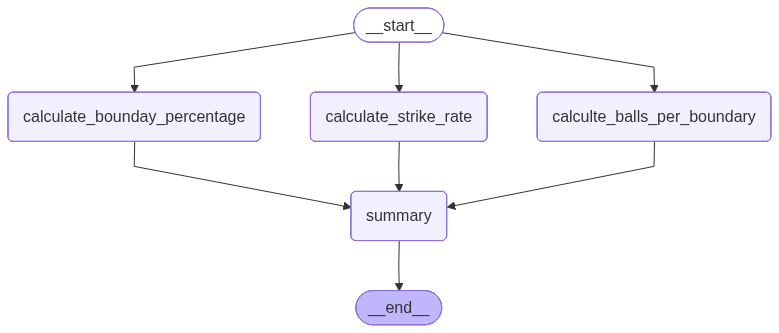

In [23]:
graph = StateGraph(CricketState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_bounday_percentage', calculate_bounday_percentage)
graph.add_node('calculte_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_bounday_percentage')
graph.add_edge(START, 'calculte_balls_per_boundary')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_bounday_percentage', 'summary')
graph.add_edge('calculte_balls_per_boundary', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

workflow

In [24]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 6
}

final_state = workflow.invoke(initial_state)
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 6,
 'strike_rate': 200.0,
 'boundary_percentage': 60.0,
 'ball_per_boundary': 4.166666666666667,
 'summary': 'Strike rate: 200.0, Boundary Percentage: 60.0, Balls Per Boundary: 4.166666666666667'}